In [44]:
import pandas as pd 

df = pd.read_excel('Dataset_SLE_T2T_forML_20241104_for_Giannis_extended(1).xlsx')


In [46]:
df.SDI

AttributeError: 'DataFrame' object has no attribute 'SDI'

In [2]:
filtered_s2k = [col for col in df.columns if 'S2K_item_' in col][:24]
other_drugs = ['Number_mod_severe_drugs', 'Drug_use_score1', 'Drug_use_score2','Delta_treatment_score']


filtered_columns = []

filtered_columns.append(df.SLET2T_ID.name)
filtered_columns.extend(filtered_s2k)

filtered_columns.append(df.Cumulative_prednisolone_intake_daily_category.name)
filtered_columns.extend(other_drugs)

df = df[filtered_columns]


In [34]:
from tensorflow.keras.layers import Input,Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
import tensorflow

s2k = df.iloc[:,1:25]
target = df.iloc[:,28].apply(lambda x: x if x==0 else 1)

x_train, x_test, y_train, y_test = train_test_split(s2k, target, test_size=0.15, shuffle=True)

In [35]:
y_train = tensorflow.keras.utils.to_categorical(y_train)
y_test = tensorflow.keras.utils.to_categorical(y_test)

In [36]:
input_dim = Input((s2k.shape[1],))

fc1 = Dense(32, activation='relu')(input_dim)
do1 = Dropout(0.2)(fc1)
fc2 = Dense(64, activation='relu')(do1)
do2 = Dropout(0.2)(fc2)
fc3 = Dense(128, activation='relu')(do2)
do3 = Dropout(0.2)(fc3)
fc4 = Dense(64, activation='relu')(do3)
fc5 = Dense(32, activation='relu')(fc4)
out = Dense(2, activation='softmax')(fc5)

model = Model(input_dim,out)

model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])


Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7413 - loss: 0.5949 - val_accuracy: 0.7909 - val_loss: 0.5132
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7510 - loss: 0.5628 - val_accuracy: 0.7909 - val_loss: 0.5101
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7432 - loss: 0.5702 - val_accuracy: 0.7909 - val_loss: 0.5112
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7532 - loss: 0.5557 - val_accuracy: 0.7909 - val_loss: 0.5122
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7598 - loss: 0.5511 - val_accuracy: 0.7909 - val_loss: 0.5115
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7434 - loss: 0.5676 - val_accuracy: 0.7909 - val_loss: 0.5217
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7509 - loss: 0.5537 - val_accuracy: 0.7909 - val_loss: 0.5126
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7440 - loss: 0.5694 - val_accuracy: 0.7909 - val_loss:

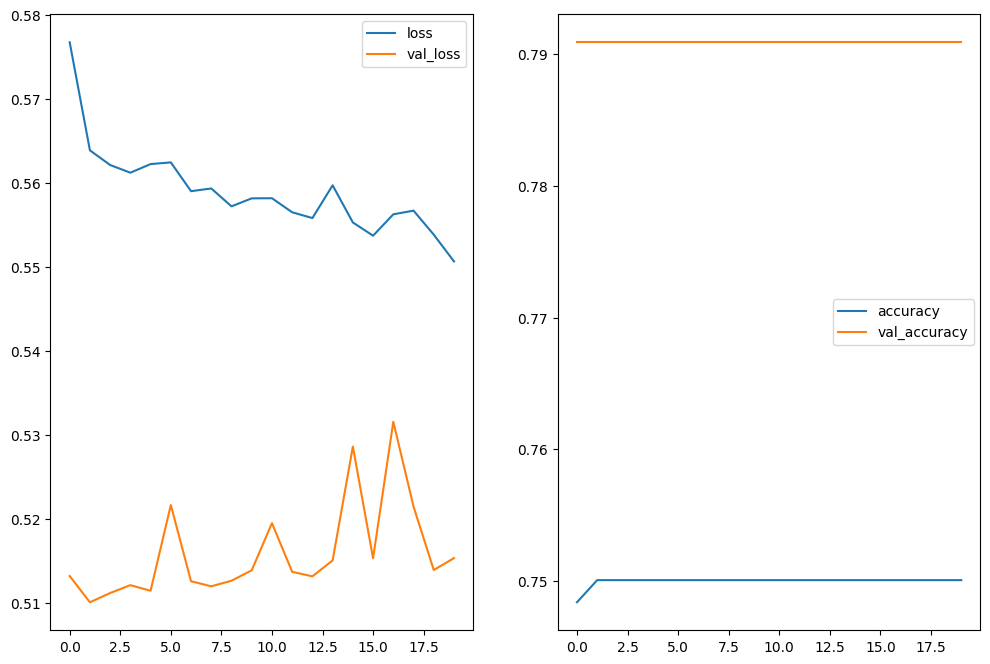

In [37]:
history = model.fit(x_train,y_train,epochs=20,validation_data=(x_test,y_test))

import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss','val_loss'])

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy','val_accuracy'])

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

clf = RandomForestClassifier(n_estimators=100)

clf.fit(x_train,y_train)

preds = clf.predict(x_test)

print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       0.31      0.05      0.08       110
           1       0.79      0.97      0.87       416

   micro avg       0.78      0.78      0.78       526
   macro avg       0.55      0.51      0.48       526
weighted avg       0.69      0.78      0.71       526
 samples avg       0.78      0.78      0.78       526



In [39]:
def og_autoencoder(input_dim=input_dim, encoding_dim=2):

            input_layer = Input(shape=(input_dim,))

            # Encoder
            encoded = Dense(128, activation='relu', name='128_encoder')(input_layer)
            encoded = Dense(64, activation='relu', name='64_encoder')(encoded)
            encoded = Dense(32, activation='relu', name='32_encoder')(encoded)
            encoded = Dense(encoding_dim, activation='relu', name='output_encoder')(encoded)

            # Decoder
            decoded = Dense(32, activation='relu', name='32_decoder')(encoded)
            decoded = Dense(64, activation='relu', name='64_decoder')(decoded)
            decoded = Dense(128, activation='relu', name='128_decoder')(decoded)
            decoded = Dense(input_dim, activation='tanh', name='output_decoder')(decoded)

            # Autoencoder
            autoencoder = Model(input_layer, decoded)

            autoencoder.compile(optimizer='adam', loss='mse')
            
            return autoencoder

ae = og_autoencoder(input_dim=s2k.shape[1])

In [40]:
s2k_0 = s2k[df.iloc[:,25]==0]
s2k_1 = s2k[df.iloc[:,25]==1]

In [41]:
def is_outside_distribution(prediction, mean, std, threshold=1.5):
    z_score = (prediction - mean) / std
    return abs(z_score) > threshold

In [42]:
from tensorflow.keras.losses import MeanSquaredError
import numpy as np
mse = MeanSquaredError()

ae.compile(optimizer='adam',loss='mse')
ae.fit(s2k_0, s2k_0, epochs=20)
train_preds = ae.predict(s2k_0)
train_losses = [mse(truth,pred) for truth,pred in zip(s2k_0.values,train_preds)]
train_mean = np.mean(train_losses)
train_std = np.std(train_losses)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0399 
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0231 
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0186 
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0174 
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0146 
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0142 
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0141 
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0139 
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0122 
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0119 
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0120 
Epoch 12/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0115 
Epoch 13/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0114 
Epoch 14/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0096 
Epoch 15/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0105 
Epoc

In [43]:
test_preds = ae.predict(s2k_1,verbose=0)
test_losses = [mse(truth,pred) for truth,pred in zip(s2k_1.values,test_preds)]
labels = [is_outside_distribution(loss,train_mean,train_std).numpy() for loss in test_losses]
results = sum(labels)
print(f'Number of predicted cort >= 1: {results}')

Number of predicted cort >= 1: 341
